# 🏙️ Yield de Aluguel e Segmentação de Imóveis — Palmas/TO

Extensão do projeto de [previsão de preços](01_eda_modelagem.ipynb). Aqui combinamos os dados
de **venda** e **aluguel** (coletados pelo mesmo scraper, `--operacao venda|aluguel`) para responder
duas perguntas de investimento e de mercado:

1. **Em quais bairros comprar para alugar rende mais?** (yield bruto anual)
2. **Quais segmentos naturais de imóveis existem no mercado?** (clustering K-Means)

## 1. Setup e carga (venda + aluguel)

In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
IMG = "../images"

RESIDENCIAIS = ["casa", "apartamento", "cobertura", "flat", "casa em condominio", "sobrado"]

def carregar(operacao):
    arq = max(glob.glob(f"../data/raw/imoveis_{operacao}_*.csv"), key=os.path.getmtime)
    print(f"{operacao}: {os.path.basename(arq)}")
    return pd.read_csv(arq)

venda = carregar("venda")
aluguel = carregar("aluguel")

venda: imoveis_venda_palmas_20260616.csv
aluguel: imoveis_aluguel_palmas_20260616.csv


## 2. Limpeza

Mesma lógica do notebook 01, mas com **faixas de outlier específicas por operação** — um aluguel
plausível vive em outra escala (centenas a milhares/mês) que um preço de venda (centenas de milhares).

In [2]:
def limpar(df, operacao):
    df = df[df["tipo"].isin(RESIDENCIAIS)].dropna(subset=["preco", "area_util"]).copy()
    df = df[(df["area_util"] >= 20) & (df["area_util"] <= 2000)]
    df["preco_m2"] = df["preco"] / df["area_util"]
    if operacao == "venda":
        df = df[(df["preco"] >= 50_000) & (df["preco"] <= 10_000_000)]
        df = df[df["preco_m2"].between(500, 30_000)]
    else:  # aluguel mensal
        df = df[(df["preco"] >= 300) & (df["preco"] <= 50_000)]
        df = df[df["preco_m2"].between(5, 300)]
    return df

venda = limpar(venda, "venda")
aluguel = limpar(aluguel, "aluguel")
print(f"Venda residencial: {len(venda)} | Aluguel residencial: {len(aluguel)}")
print(f"Aluguel mediano: R$ {aluguel['preco'].median():,.0f}/mês "
      f"({aluguel['preco_m2'].median():.1f} R$/m²)")

Venda residencial: 939 | Aluguel residencial: 56
Aluguel mediano: R$ 3,600/mês (50.4 R$/m²)


## 3. Yield de aluguel por bairro

O **yield bruto anual** estima o retorno de comprar para alugar:

$$\text{yield} = \frac{\text{aluguel mensal} \times 12}{\text{preço de venda}}$$

Como venda e aluguel são anúncios **diferentes** (não dá para casar imóvel a imóvel), normalizamos
por **m²** e comparamos as **medianas por bairro** — o que torna o cálculo independente do tamanho
do imóvel. Consideramos só bairros com amostra suficiente (≥ 5 vendas e ≥ 3 aluguéis).

In [3]:
vb = venda.groupby("bairro").agg(venda_m2=("preco_m2", "median"), n_venda=("preco", "size"))
ab = aluguel.groupby("bairro").agg(aluguel_m2=("preco_m2", "median"), n_alug=("preco", "size"))

y = vb.join(ab, how="inner")
y = y[(y["n_venda"] >= 5) & (y["n_alug"] >= 3)]
y["yield_anual_%"] = (y["aluguel_m2"] * 12) / y["venda_m2"] * 100
y = y.sort_values("yield_anual_%", ascending=False)

# yield agregado da cidade (referência)
yield_cidade = (aluguel["preco_m2"].median() * 12) / venda["preco_m2"].median() * 100
print(f"Yield bruto anual da cidade (referência): {yield_cidade:.2f}%")
y.round(2)

Yield bruto anual da cidade (referência): 9.50%


,venda_m2,n_venda,aluguel_m2,n_alug,yield_anual_%
bairro,,,,,
Plano Diretor Sul,6378.30,634,53.53,32,10.07
Plano Diretor Norte,5654.76,131,35.53,14,7.54
Graciosa - Orla 14,13088.38,62,73.91,7,6.78


C:\Users\augus\AppData\Local\Temp\ipykernel_3900\3074139621.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=y["yield_anual_%"], y=y.index, palette="crest")


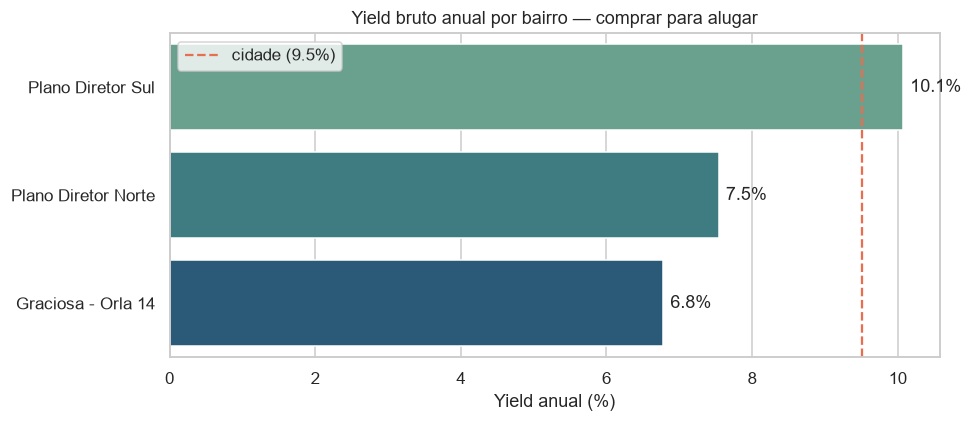

In [4]:
plt.figure(figsize=(9, 4))
ax = sns.barplot(x=y["yield_anual_%"], y=y.index, palette="crest")
ax.axvline(yield_cidade, ls="--", color="#E76F51", label=f"cidade ({yield_cidade:.1f}%)")
for i, v in enumerate(y["yield_anual_%"]):
    ax.text(v + 0.1, i, f"{v:.1f}%", va="center")
plt.title("Yield bruto anual por bairro — comprar para alugar")
plt.xlabel("Yield anual (%)"); plt.ylabel(""); plt.legend()
plt.tight_layout(); plt.savefig(f"{IMG}/yield_bairro.png", bbox_inches="tight"); plt.show()

> **Insight de investimento:** o bairro **mais caro para comprar não é o que mais rende**.
> Graciosa/Orla 14 tem o maior preço por m² (~R$ 13 mil) mas o **menor yield** — o aluguel não
> acompanha o prêmio do imóvel. Já o **Plano Diretor Sul** combina preço acessível e bom aluguel,
> entregando o **maior retorno bruto anual**. É o padrão clássico: áreas nobres se pagam pela
> valorização, não pela renda de aluguel.
>
> ⚠️ *O mercado de locação anunciado em Palmas é pequeno (~50 imóveis), então o yield é robusto
> apenas para os bairros principais; é um indicativo direcional, não um número de contrato.*

## 4. Segmentação de imóveis (K-Means)

Em vez de regras manuais ("imóvel caro/barato"), deixamos o algoritmo encontrar **grupos naturais**
de imóveis a partir de preço, área, quartos, banheiros, vagas e preço/m². Reaproveitamos a
metodologia do projeto de segmentação de clientes: log-transform + padronização + escolha de *k*
por cotovelo e silhueta.

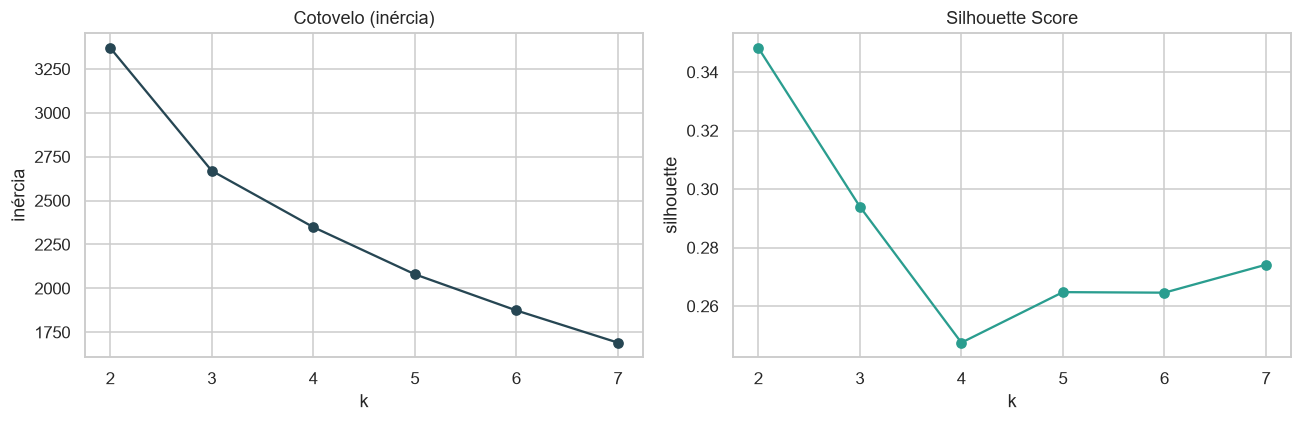

In [5]:
feats = ["preco", "area_util", "quartos", "banheiros", "vagas", "preco_m2"]
base = venda.dropna(subset=["quartos"]).copy()
base["vagas"] = base["vagas"].fillna(0)
base["banheiros"] = base["banheiros"].fillna(base["banheiros"].median())

X = StandardScaler().fit_transform(np.log1p(base[feats]))

ks = range(2, 8)
inercias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inercias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(ks), inercias, "o-", color="#264653"); ax[0].set_title("Cotovelo (inércia)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("inércia")
ax[1].plot(list(ks), sils, "o-", color="#2A9D8F"); ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("k"); ax[1].set_ylabel("silhouette")
plt.tight_layout(); plt.savefig(f"{IMG}/elbow_silhouette_imoveis.png", bbox_inches="tight"); plt.show()

> A silhueta é máxima em k=2, que apenas separaria "barato" de "caro" — pouco útil. Escolhemos
> **k=4**, que revela uma escada de mercado acionável sem fragmentar demais (mesma lógica do projeto
> de segmentação de clientes: estatística + utilidade de negócio).

In [6]:
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X)
base["cluster"] = km.labels_

# nomear os segmentos de forma determinística, pela mediana de preço (escada de mercado)
ordem = base.groupby("cluster")["preco"].median().sort_values().index
nomes = ["Compacto / Entrada", "Padrão Médio", "Médio-Alto / Amplo", "Alto Padrão"]
mapa = {c: n for c, n in zip(ordem, nomes)}
base["segmento"] = base["cluster"].map(mapa)

perfil = base.groupby("segmento").agg(
    imoveis=("preco", "size"),
    preco_mediano=("preco", "median"),
    area_mediana=("area_util", "median"),
    quartos=("quartos", "median"),
    vagas=("vagas", "median"),
    preco_m2=("preco_m2", "median"),
).reindex(nomes)
perfil.round(0)

,imoveis,preco_mediano,area_mediana,quartos,vagas,preco_m2
segmento,,,,,,
Compacto / Entrada,195,380000.0,63.0,2.0,1.0,5426.0
Padrão Médio,318,680000.0,120.0,3.0,2.0,5667.0
Médio-Alto / Amplo,269,1220000.0,187.0,3.0,3.0,6486.0
Alto Padrão,156,3300000.0,305.0,4.0,4.0,12000.0


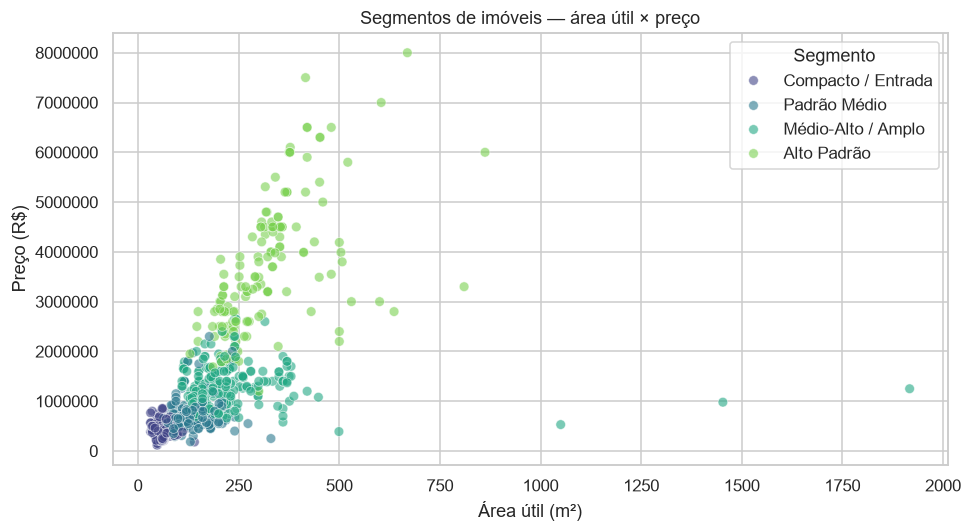

In [7]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=base, x="area_util", y="preco", hue="segmento",
                hue_order=nomes, palette="viridis", alpha=0.6, s=40)
plt.title("Segmentos de imóveis — área útil × preço")
plt.xlabel("Área útil (m²)"); plt.ylabel("Preço (R$)")
plt.ticklabel_format(style="plain", axis="y")
plt.legend(title="Segmento")
plt.tight_layout(); plt.savefig(f"{IMG}/segmentos_scatter.png", bbox_inches="tight"); plt.show()

> Os quatro segmentos formam uma progressão clara do mercado de Palmas:
>
> | Segmento | Perfil | Uso |
> |----------|--------|-----|
> | **Compacto / Entrada** | ~R$ 380 mil, 63 m², 2 quartos | Primeiro imóvel, investidor de locação |
> | **Padrão Médio** | ~R$ 680 mil, 120 m², 3 quartos | Família típica |
> | **Médio-Alto / Amplo** | ~R$ 1,2 mi, 187 m², 3 quartos, 3 vagas | Upgrade familiar |
> | **Alto Padrão** | ~R$ 3,3 mi, 305 m², 4 quartos, R$ 12 mil/m² | Luxo |

## 5. Conclusões

- **Yield:** o Plano Diretor Sul oferece o melhor retorno de aluguel; áreas nobres (Graciosa) rendem
  menos proporcionalmente — útil para decisão de compra para investimento vs. moradia.
- **Segmentação:** o mercado se organiza em 4 faixas claras (entrada → alto padrão), uma "escada"
  que pode orientar precificação, anúncios e foco comercial.
- **Pipeline reaproveitado:** o mesmo scraper alimentou três análises (preço, yield, segmentação),
  e a metodologia de clustering veio direto do projeto de segmentação de clientes.

### Próximas etapas
- [ ] Ampliar a coleta de aluguel (mais cidades) para yield robusto em mais bairros
- [ ] Cruzar segmento × yield: qual faixa de imóvel rende mais aluguel?
- [ ] Servir tudo via API (FastAPI): preço estimado, segmento e yield do bairro em um endpoint